# Qwen3-14B retail: SFT training + rejection-sampling rollouts

**Section 1** is the single-turn ground-truth-distillation SFT run (500 retail train tasks, instruction dumped upfront as one user message). This training converged cleanly (final loss 0.4724) but **caused a catastrophic eval regression (0.452 -> 0.026 avg reward)** -- the model learned to fire tool calls immediately on any user message instead of gathering info across turns, since every training example had the complete request available upfront. Kept here as a documented negative result, not reused.

**Section 2** is the fix: real multi-turn rollouts, generated by running the actual base (non-fine-tuned) model against the real τ-bench env + GPT-4o user-simulator, up to 2 tries per train task, keeping only genuinely passing (reward=1.0) trajectories as new SFT data.

## Section 1: single-turn SFT run (abandoned)

37 logged steps, latest loss = 0.4139 at epoch 2.94


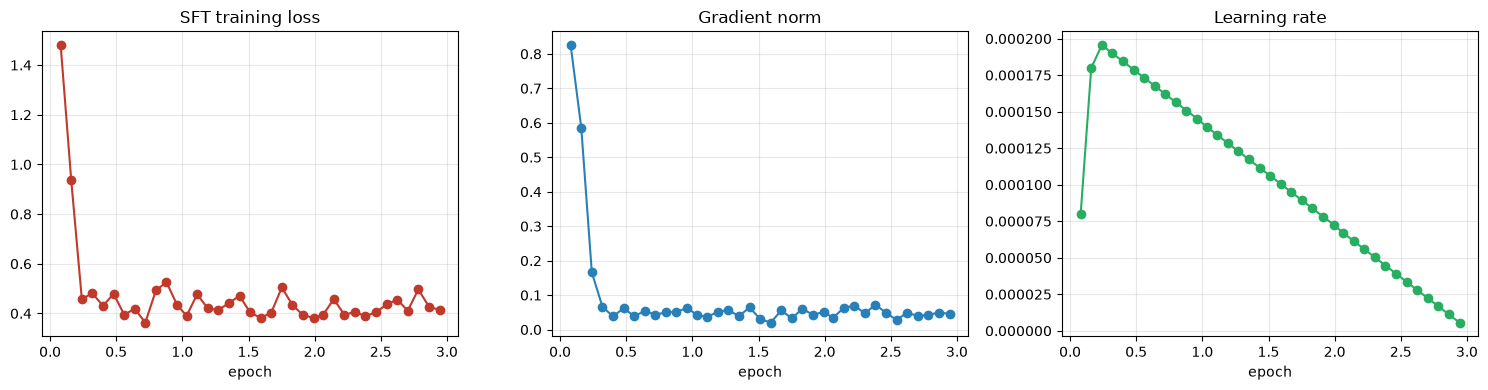

In [4]:
import json
import matplotlib.pyplot as plt

records = json.load(open("full_run_results/qwen3_14b_train_metrics.json"))
epochs = [r["epoch"] for r in records]
losses = [r["loss"] for r in records]
grad_norms = [r["grad_norm"] for r in records]
lrs = [r["learning_rate"] for r in records]
print(f"{len(records)} logged steps, latest loss = {losses[-1]:.4f} at epoch {epochs[-1]:.2f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(epochs, losses, marker="o", color="#c0392b"); axes[0].set_title("SFT training loss"); axes[0].set_xlabel("epoch"); axes[0].grid(alpha=0.3)
axes[1].plot(epochs, grad_norms, marker="o", color="#2980b9"); axes[1].set_title("Gradient norm"); axes[1].set_xlabel("epoch"); axes[1].grid(alpha=0.3)
axes[2].plot(epochs, lrs, marker="o", color="#27ae60"); axes[2].set_title("Learning rate"); axes[2].set_xlabel("epoch"); axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Section 2: rejection-sampling rollout generation (current, in progress)

500/500 tasks done, 422 passed, 78 skipped, cost so far $1.41


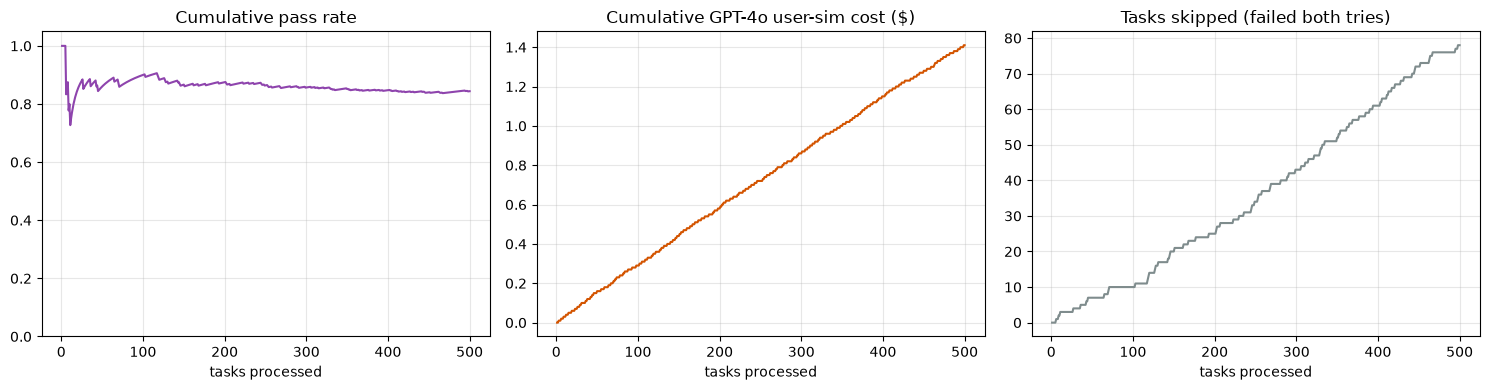

In [5]:
import json
import matplotlib.pyplot as plt

records = json.load(open("full_run_results/rollout_progress.json"))
if not records:
    print("no rollout progress data yet -- job may have just (re)started, try again in a few minutes")
else:
    task = [r["task"] for r in records]
    pass_rate = [r["passed"] / r["task"] for r in records]
    cost = [r["cost"] for r in records]
    skipped = [r["skipped"] for r in records]
    latest = records[-1]
    print(f"{latest['task']}/{latest['total']} tasks done, {latest['passed']} passed, {latest['skipped']} skipped, cost so far ${latest['cost']:.2f}")

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(task, pass_rate, color="#8e44ad"); axes[0].set_title("Cumulative pass rate"); axes[0].set_xlabel("tasks processed"); axes[0].set_ylim(0, 1.05); axes[0].grid(alpha=0.3)
    axes[1].plot(task, cost, color="#d35400"); axes[1].set_title("Cumulative GPT-4o user-sim cost ($)"); axes[1].set_xlabel("tasks processed"); axes[1].grid(alpha=0.3)
    axes[2].plot(task, skipped, color="#7f8c8d"); axes[2].set_title("Tasks skipped (failed both tries)"); axes[2].set_xlabel("tasks processed"); axes[2].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


## Section 3: SFT on the 422 real multi-turn rollouts -- attempt 1 (superseded)

QLoRA r=16, 3 epochs, max_seq_length=16384, only the final epoch-3 adapter kept (`save_total_limit=1`). Training loss looked great (converged to 0.029) -- but loss dropped to near-zero (~0.003-0.03) by as early as epoch 0.3, a sign of fast memorization on only 422 examples. Confirmed at eval time: the model fired tool calls immediately with **fabricated placeholder values** (`user@example.com`, `"John Doe"`, zip `"12345"`) instead of asking the real user for missing info -- rote memorization of the training set's argument patterns, not learned behavior. The one intermediate checkpoint (epoch 2) had already been deleted by the time this was diagnosed, so there was no earlier snapshot to fall back to. Loss values below are reconstructed from the session's own progress log (the raw training log was overwritten when attempt 2 was launched).

27 logged steps, latest loss = 0.0109 at epoch 2.93


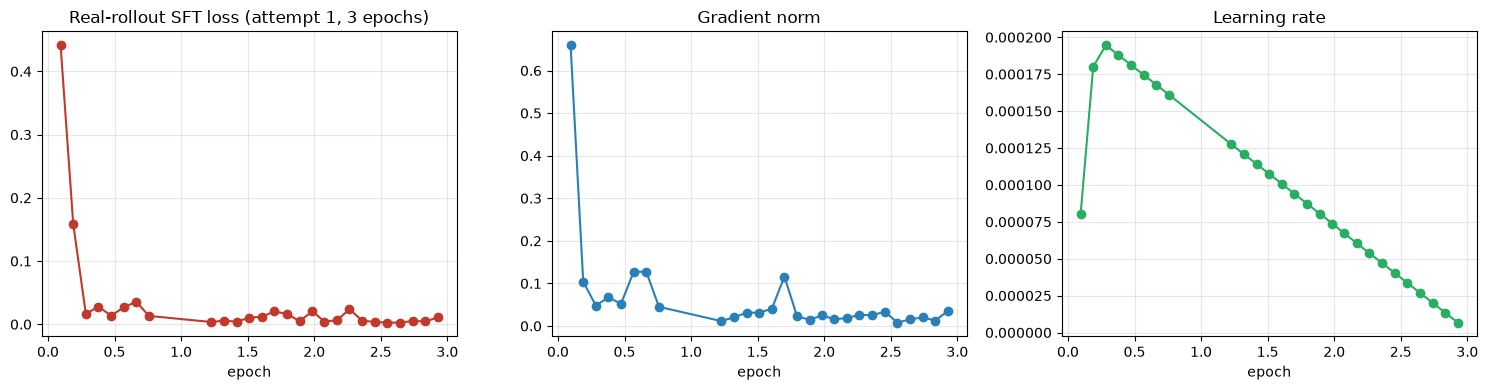

In [6]:
import json
import matplotlib.pyplot as plt

records = json.load(open("full_run_results/qwen3_14b_rollout_train_v1_metrics.json"))
epochs = [r["epoch"] for r in records]
losses = [r["loss"] for r in records]
grad_norms = [r["grad_norm"] for r in records]
lrs = [r["learning_rate"] for r in records]
print(f"{len(records)} logged steps, latest loss = {losses[-1]:.4f} at epoch {epochs[-1]:.2f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(epochs, losses, marker="o", color="#c0392b"); axes[0].set_title("Real-rollout SFT loss (attempt 1, 3 epochs)"); axes[0].set_xlabel("epoch"); axes[0].grid(alpha=0.3)
axes[1].plot(epochs, grad_norms, marker="o", color="#2980b9"); axes[1].set_title("Gradient norm"); axes[1].set_xlabel("epoch"); axes[1].grid(alpha=0.3)
axes[2].plot(epochs, lrs, marker="o", color="#27ae60"); axes[2].set_title("Learning rate"); axes[2].set_xlabel("epoch"); axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Section 4: SFT on the 422 real multi-turn rollouts -- attempt 2 (current)

Same data and LoRA config as attempt 1, but **1 epoch only** (~53 steps total) and **checkpointing every 5 steps** (`save_strategy="steps"`, `save_steps=5`, `save_total_limit=12`) instead of once at the end. Since attempt 1's loss was already suspiciously low by step 15-20, the goal is to grab and evaluate one of the very early checkpoints (step 5 first) before memorization sets in, rather than training to full convergence and hoping it generalizes.

1 logged steps, latest loss = 0.4413 at epoch 0.09


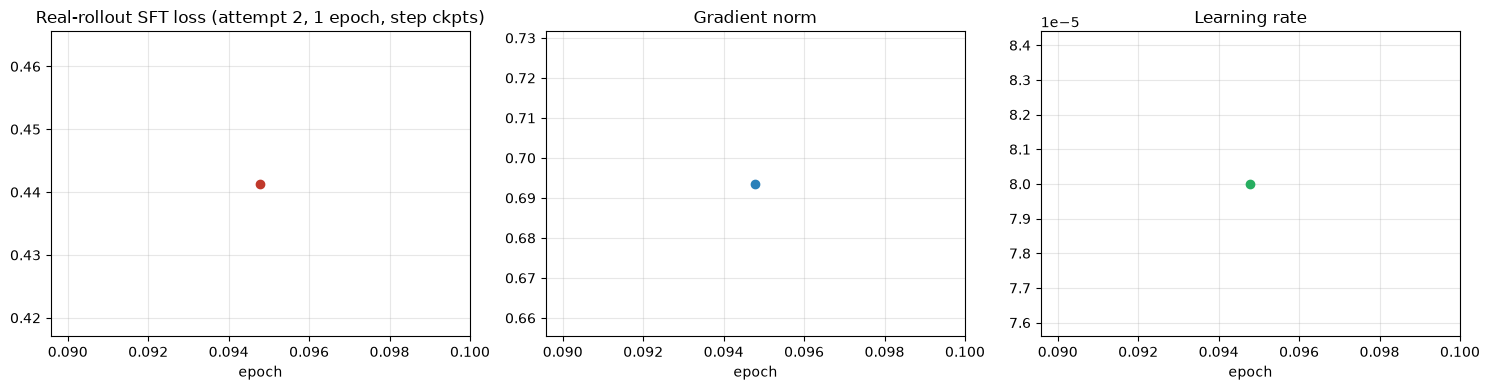

In [7]:
import json
import matplotlib.pyplot as plt

records = json.load(open("full_run_results/qwen3_14b_rollout_train_metrics.json"))
if not records:
    print("no training data yet -- job may still be downloading the base model")
else:
    epochs = [r["epoch"] for r in records]
    losses = [r["loss"] for r in records]
    grad_norms = [r["grad_norm"] for r in records]
    lrs = [r["learning_rate"] for r in records]
    print(f"{len(records)} logged steps, latest loss = {losses[-1]:.4f} at epoch {epochs[-1]:.2f}")

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(epochs, losses, marker="o", color="#c0392b"); axes[0].set_title("Real-rollout SFT loss (attempt 2, 1 epoch, step ckpts)"); axes[0].set_xlabel("epoch"); axes[0].grid(alpha=0.3)
    axes[1].plot(epochs, grad_norms, marker="o", color="#2980b9"); axes[1].set_title("Gradient norm"); axes[1].set_xlabel("epoch"); axes[1].grid(alpha=0.3)
    axes[2].plot(epochs, lrs, marker="o", color="#27ae60"); axes[2].set_title("Learning rate"); axes[2].set_xlabel("epoch"); axes[2].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


## Section 5: τ-bench retail eval results, side by side

All runs are the full 115-task retail test split, GPT-4o as the user-simulator, same policy/tools/harness. **Baseline** is the untrained Qwen3-14B-AWQ. **Overfit** is the single-turn-SFT-trained model from Section 1 (catastrophic collapse). **Step 5** is the Section 4 run stopped at step 5 (~9% into epoch 1) -- essentially matches baseline, confirming that little training happened yet. Later checkpoints (step 10, 15...) get added here as they're evaluated, to find the point where real improvement (if any) shows up before memorization takes over.

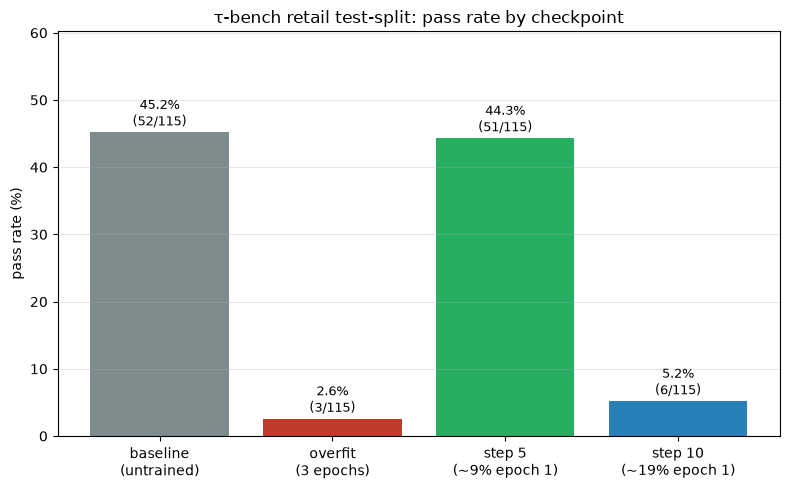

In [8]:
import json
import matplotlib.pyplot as plt

records = json.load(open("full_run_results/tau_eval_comparison.json"))
if not records:
    print("no eval comparison data yet")
else:
    labels = [r["label"] for r in records]
    pct = [100 * r["pass"] / r["total"] for r in records]
    colors = ["#7f8c8d", "#c0392b", "#27ae60", "#2980b9", "#8e44ad"][:len(records)]

    fig, ax = plt.subplots(1, 1, figsize=(8, 5))
    bars = ax.bar(labels, pct, color=colors)
    for bar, r in zip(bars, records):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f"{100*r['pass']/r['total']:.1f}%\n({r['pass']}/{r['total']})", ha="center", fontsize=9)
    ax.set_ylabel("pass rate (%)")
    ax.set_title("τ-bench retail test-split: pass rate by checkpoint")
    ax.set_ylim(0, max(pct) + 15)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


## Section 6: pivot from SFT to RL (GRPO), same reward tau-bench itself uses

Root cause of the SFT collapse (see the `qwen3-14b-tau-train-overfitting` repo): a **positional shortcut**, not simple memorization -- 99.1% of training examples called the auth function, and 98% of those did it at the exact same message index (turn 4), teaching the model "fire auth around turn 4" instead of conditioning on whether real info was actually given. A data-level fix (the augmented dataset: zip/email-withheld negatives, policy-refusal examples, out-of-stock/nonexistent-lookup examples, all grounded in tau-bench's real orders/users/products DB) helps diversify the *targets*, but SFT still teaches "reproduce this one correct trajectory" -- so we're pivoting to RL, which only needs a pass/fail signal and lets the model find its own correct trajectories.

**Reward**: exactly tau-bench's own `calculate_reward()` (`tau_bench/envs/base.py`) -- no custom scoring. It replays the task's ground-truth mutating actions on a fresh copy of the retail DB, hashes the result, and compares to the hash produced by the agent's actual trajectory: reward = 1.0 iff they match (plus an optional output string-match check), else 0.0. Read-only tools (`calculate`, `find_user_id_by_email`, `find_user_id_by_name_zip`, `get_order_details`, `get_product_details`, `get_user_details`, `list_all_product_types`, `think`) never touch `self.data`, so they're naturally excluded from scoring either way -- only the 8 mutating tools (`cancel_pending_order`, `exchange_delivered_order_items`, `modify_pending_order_address`, `modify_pending_order_items`, `modify_pending_order_payment`, `modify_user_address`, `return_delivered_order_items`, `transfer_to_human_agents`) can move the hash off ground truth.

**Setup** (`grpo_train.py`, on a fresh RunPod A100-80GB pod since the previous one was terminated):
- Base model: `unsloth/Qwen3-14B-unsloth-bnb-4bit`, QLoRA r=16 (same target modules/config as the SFT runs), served from vLLM (`--quantization bitsandbytes --enable-lora`) **and** loaded separately via unsloth for the gradient updates -- one model, two roles, to avoid downloading/maintaining two quantization formats on the 30GB pod disk.
- Rollouts: tau-bench's own `ToolCallingAgent.solve()` reused unmodified, pointed at the vLLM server via litellm's `hosted_vllm` provider (isolated from `OPENAI_API_BASE`, which stays on `api.openai.com` for the GPT-4o user-simulator so both endpoints coexist). G=4 rollouts per task, temperature=1.0 for exploration.
- Advantage: standard GRPO group-relative normalization per task, `(r_i - mean(r_group)) / (std(r_group) + eps)`; tasks whose whole group scored identically (all-0 or all-1) are skipped -- no learning signal.
- Update: since vLLM (not the trainer) generated the tokens, logprobs of the exact assistant spans are recomputed via a teacher-forced forward pass on the trainer-side model (same `train_on_responses_only`-style masking as SFT -- only assistant tokens contribute). Loss per rollout = `-advantage * mean(logprob(assistant tokens))`. After each round the LoRA adapter is saved and hot-reloaded into vLLM via `/v1/load_lora_adapter`.
- First pass config: 4 tasks/round x 4 rollouts = 16 episodes/round, `lr=1e-5`, checkpointed every 5 rounds. Meant to be tuned once the mechanics are confirmed working.

11 rounds logged, latest avg_reward = 0.500 at round 10


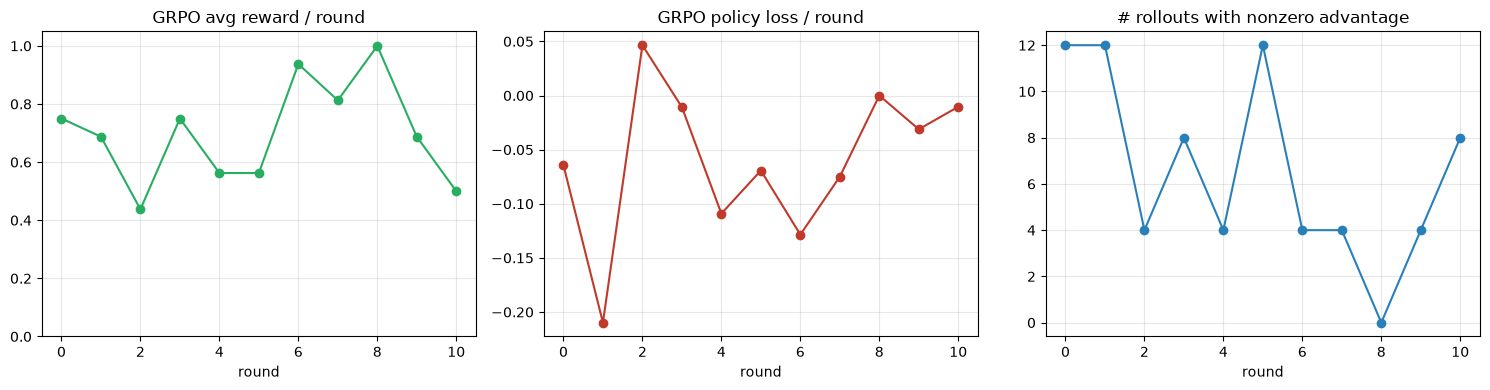

In [10]:
import json
import matplotlib.pyplot as plt

try:
    records = [json.loads(line) for line in open("full_run_results/grpo_train_log.jsonl")]
except FileNotFoundError:
    records = []
if not records:
    print("no GRPO training data yet -- job may still be starting up (vLLM model download, first rollouts)")
else:
    rounds = [r["round"] for r in records]
    avg_reward = [r["avg_reward"] for r in records]
    avg_loss = [r["avg_loss"] for r in records]
    n_updated = [r["n_updated"] for r in records]
    print(f"{len(records)} rounds logged, latest avg_reward = {avg_reward[-1]:.3f} at round {rounds[-1]}")

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(rounds, avg_reward, marker="o", color="#27ae60"); axes[0].set_title("GRPO avg reward / round"); axes[0].set_xlabel("round"); axes[0].set_ylim(0, 1.05); axes[0].grid(alpha=0.3)
    axes[1].plot(rounds, avg_loss, marker="o", color="#c0392b"); axes[1].set_title("GRPO policy loss / round"); axes[1].set_xlabel("round"); axes[1].grid(alpha=0.3)
    axes[2].plot(rounds, n_updated, marker="o", color="#2980b9"); axes[2].set_title("# rollouts with nonzero advantage"); axes[2].set_xlabel("round"); axes[2].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


### Eval probe (the number that actually matters)

The chart above is the **training-time** reward -- noisy, small-batch (4 tasks/round), and mixes easy/hard tasks by luck of the draw, so it bounces around and can't tell us if the model is really improving. Every 5 rounds, a saved checkpoint is loaded into vLLM under its own adapter name (without touching the live training adapter) and run at temperature=0 against 20 fixed, real τ-bench **test**-split tasks (never seen during training, which only samples from the train split). That gives one clean, comparable number per checkpoint.

In [ ]:
import json
import matplotlib.pyplot as plt

try:
    records = json.load(open("full_run_results/grpo_eval_probe_log.json"))
except FileNotFoundError:
    records = []

if not records:
    print("no eval probe data yet")
else:
    original = sorted([r for r in records if r.get("run", "original") == "original"], key=lambda r: r["round"])
    rerun = sorted([r for r in records if r.get("run") == "rerun_with_transcripts"], key=lambda r: r["round"])
    best = max(records, key=lambda r: r["probe_avg_reward"])
    print(f"{len(records)} probe runs logged. best so far: round {best['round']} ({best.get('run','original')}) at {best['probe_avg_reward']:.2f}")

    fig, ax = plt.subplots(1, 1, figsize=(9, 5))

    # small horizontal offset so the two lines never sit exactly on top of
    # each other even where their values coincide (round 5, round 10)
    if original:
        x = [r["round"] - 0.15 for r in original]
        y = [r["probe_avg_reward"] for r in original]
        ax.plot(x, y, marker="o", markersize=9, color="#8e44ad", linewidth=2.5, label="original (drove the stop decision)", zorder=3)
        for xi, yi in zip(x, y):
            ax.annotate(f"{yi:.2f}", (xi, yi), textcoords="offset points", xytext=(-4, 10), ha="right", fontsize=9, color="#8e44ad")
    if rerun:
        x = [r["round"] + 0.15 for r in rerun]
        y = [r["probe_avg_reward"] for r in rerun]
        ax.plot(x, y, marker="s", markersize=9, color="#d35400", linewidth=2.5, label="rerun (dialogues saved)", zorder=3)
        for xi, yi in zip(x, y):
            ax.annotate(f"{yi:.2f}", (xi, yi), textcoords="offset points", xytext=(4, -14), ha="left", fontsize=9, color="#d35400")

    ax.set_title("Eval probe: pass rate on 20 fixed real test tasks, by checkpoint")
    ax.set_xlabel("training round")
    ax.set_ylabel("pass rate")
    ax.set_xticks(sorted(set(r["round"] for r in records)))
    ax.set_ylim(0, 0.75)
    ax.legend(fontsize=10, loc="upper right")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
